In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def calculate_polygon_area(x, y):
    """
    Calculates the area of a polygon using the Shoelace formula.
    REQUIRES: The last point must close the polygon (same as first point).
    """
    x = np.array(x)
    y = np.array(y)

    # SANITY: Polygon must have at least 3 unique vertices + 1 closing point
    assert len(x) >= 4, f"Polygon must have >= 4 points (3 vertices + closing). Got {len(x)}."
    assert len(x) == len(y), f"x and y must have equal length. Got x={len(x)}, y={len(y)}."
    assert np.isclose(x[0], x[-1]) and np.isclose(y[0], y[-1]), \
        f"Last point {(x[-1], y[-1])} must close polygon at {(x[0], y[0])}."

    area = 0.5 * np.abs(np.dot(x[:-1], y[1:]) - np.dot(x[1:], y[:-1]))

    assert area > 1e-9, f"Polygon area is near-zero ({area:.6f}). Check for collinear/duplicate vertices."
    return area


def expand_from_6dim_to_xy(x1, y1, theta1, theta2, theta3, theta4, vehicle_geometrics):

    L = vehicle_geometrics['L']  # [tractor_wb, trailer1_wb, trailer2_wb, trailer3_wb]
    M = vehicle_geometrics['M']  # [hitch_offset_0, hitch_offset_1, hitch_offset_2, hitch_offset_3]

    # SANITY: Check geometry arrays
    assert len(L) >= 4, f"L must have at least 4 elements. Got {len(L)}."
    assert len(M) >= 3, f"M must have at least 3 elements. Got {len(M)}."
    assert all(l > 0 for l in L), f"All wheelbase lengths L must be positive. Got {L}."
    assert all(m >= 0 for m in M), f"All hitch offsets M must be non-negative. Got {M}."


    x2 = x1 - M[0] * np.cos(theta1) - L[1] * np.cos(theta2)
    y2 = y1 - M[0] * np.sin(theta1) - L[1] * np.sin(theta2)

    # Trailer 2 rear axle
    x3 = x2 - M[1] * np.cos(theta2) - L[2] * np.cos(theta3)
    y3 = y2 - M[1] * np.sin(theta2) - L[2] * np.sin(theta3)

    # Trailer 3 rear axle
    x4 = x3 - M[2] * np.cos(theta3) - L[3] * np.cos(theta4)
    y4 = y3 - M[2] * np.sin(theta3) - L[3] * np.sin(theta4)

    return np.array(x2), np.array(y2), np.array(x3), np.array(y3), np.array(x4), np.array(y4)




def setup_environment(test_case_number=3.2):
    """Initializes all vehicle parameters, limits, and boundary conditions."""

    valid_cases = {1.1, 1.2, 2.1, 2.2, 3.1, 3.2}
    assert test_case_number in valid_cases, \
        f"Invalid test_case_number {test_case_number}. Must be one of {valid_cases}."

    case_id = round(test_case_number)
    off_axle_flag = 1 if round(test_case_number * 10) % 10 == 2 else 0

    print(f"[INIT] Test Case: {test_case_number} | Case ID: {case_id} | Off-axle hitch: {'YES' if off_axle_flag else 'NO'}")

    planning_scale = {
        'xmin': -30.0, 'xmax': 20.0,
        'ymin': -20.0, 'ymax': 20.0,
        'xhorizon': 50.0, 'yhorizon': 40.0
    }
    assert planning_scale['xhorizon'] == planning_scale['xmax'] - planning_scale['xmin'], \
        "xhorizon must equal xmax - xmin."
    assert planning_scale['yhorizon'] == planning_scale['ymax'] - planning_scale['ymin'], \
        "yhorizon must equal ymax - ymin."

    vehicle_geometrics = {
        'L_tractor_front_hang': 0.25,
        'L_tractor_wheelbase': 1.5,
        'L_tractor_rear_hang': 0.25,
        'LHW': 1.0,                                                # Half-width
        'M': np.array([1.5, 1.5, 1.5, 1.5]) * off_axle_flag,     # Hitch offsets
        'L': np.array([3.0, 3.0, 3.0, 3.0]),                      # Wheelbases
        'L_trailer_front_hang': 1.0,
        'L_trailer_rear_hang': 1.0
    }

    assert vehicle_geometrics['L_tractor_wheelbase'] > 0, "Tractor wheelbase must be positive."
    assert vehicle_geometrics['LHW'] > 0, "Half-width must be positive."
    assert all(vehicle_geometrics['L'] > 0), "All trailer wheelbases must be positive."

    # 3. Vehicle Physics (Limits)
    vehicle_physics = {
        'v_max': 1.5,
        'phy_max': 0.7,    # Max steering angle (rad) ≈ 40 degrees
        'a_max': 0.25,
        'w_max': 0.5,
    }
    vehicle_physics['min_turning_radius'] = (
        vehicle_geometrics['L_tractor_wheelbase'] / np.tan(vehicle_physics['phy_max'])
    )

    assert 0 < vehicle_physics['phy_max'] < np.pi / 2, \
        f"Steering limit phy_max={vehicle_physics['phy_max']:.3f} must be in (0, pi/2)."
    print(f"[INIT] Min turning radius: {vehicle_physics['min_turning_radius']:.3f} m")

    # 4. Hybrid A* Parameters
    hybrid_astar = {
        'resolution_x': 0.15, 'resolution_y': 0.15, 'resolution_theta': 0.2,
        'penalty_multiplier_for_reversing': 3.0,
        'penalty_multiplier_for_drastic_direction_change': 5.0,
        'multiplier_H': 3.0,
        'num_iters_for_rs': 10,
        'max_iter': 10000,
        'terminal_xy_neiborhood': 5.0,
        'terminal_theta_neiborhood': 1.0
    }
    hybrid_astar['num_nodes_x'] = (
        int(np.ceil(planning_scale['xhorizon'] / hybrid_astar['resolution_x'])) + 1
    )
    hybrid_astar['num_nodes_y'] = (
        int(np.ceil(planning_scale['yhorizon'] / hybrid_astar['resolution_y'])) + 1
    )
    hybrid_astar['num_nodes_theta'] = (
        int(np.ceil(2 * np.pi / hybrid_astar['resolution_theta'])) + 1
    )

    print(f"[INIT] Grid size: {hybrid_astar['num_nodes_x']} x {hybrid_astar['num_nodes_y']} "
          f"x {hybrid_astar['num_nodes_theta']} (x, y, theta nodes)")

    # 5. Boundary Values (Start and Goal Configurations based on Case ID)
    bvc = {}
    if case_id == 1:
        bvc['x1_init'], bvc['y1_init'] = -15.0, -17.5
        bvc['theta1_init'] = bvc['theta2_init'] = bvc['theta3_init'] = bvc['theta4_init'] = 0.0
        bvc['xc_end'], bvc['yc_end'] = 10.0, 0.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 10.0, 1.5
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = 16.0, 0.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = 0.0
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = 0.0
    elif case_id == 2:
        bvc['x1_init'], bvc['y1_init'] = -10.0, 10.0
        bvc['theta1_init'] = bvc['theta2_init'] = bvc['theta3_init'] = bvc['theta4_init'] = 0.0
        bvc['xc_end'], bvc['yc_end'] = -2.0, 0.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 10.0, 1.25
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = 0.0, 0.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = 0.0
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = 0.0
    elif case_id == 3:
        bvc['x1_init'], bvc['y1_init'] = 16.0, 16.0
        bvc['theta1_init'] = bvc['theta2_init'] = np.pi / 6
        bvc['theta3_init'] = bvc['theta4_init'] = np.pi / 6
        bvc['xc_end'], bvc['yc_end'] = -5.0, -11.0
        bvc['x_end_half_width'], bvc['y_end_half_width'] = 1.25, 9.0
        bvc['norminal_x1_end'], bvc['norminal_y1_end'] = -5.0, -3.0
        bvc['norminal_theta1_end'] = bvc['norminal_theta2_end'] = np.pi / 2
        bvc['norminal_theta3_end'] = bvc['norminal_theta4_end'] = np.pi / 2

    # assert planning_scale['xmin'] <= bvc['x1_init'] <= planning_scale['xmax'], \
    #     f"Start x1_init={bvc['x1_init']} is outside planning bounds [{planning_scale['xmin']}, {planning_scale['xmax']}]."
    # assert planning_scale['ymin'] <= bvc['y1_init'] <= planning_scale['ymax'], \
    #     f"Start y1_init={bvc['y1_init']} is outside planning bounds [{planning_scale['ymin']}, {planning_scale['ymax']}]."
    # assert planning_scale['xmin'] <= bvc['xc_end'] <= planning_scale['xmax'], \
    #     f"Goal xc_end={bvc['xc_end']} is outside planning bounds."
    # assert planning_scale['ymin'] <= bvc['yc_end'] <= planning_scale['ymax'], \
    #     f"Goal yc_end={bvc['yc_end']} is outside planning bounds."

    print(f"[INIT] Start: ({bvc['x1_init']}, {bvc['y1_init']}), "
          f"heading={np.degrees(bvc['theta1_init']):.1f} deg")
    print(f"[INIT] Goal center: ({bvc['xc_end']}, {bvc['yc_end']}), "
          f"nominal end: ({bvc['norminal_x1_end']}, {bvc['norminal_y1_end']})")

    # Calculate nominal end positions for all trailers
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(
        bvc['norminal_x1_end'], bvc['norminal_y1_end'],
        bvc['norminal_theta1_end'], bvc['norminal_theta2_end'],
        bvc['norminal_theta3_end'], bvc['norminal_theta4_end'],
        vehicle_geometrics
    )
    bvc.update({
        'norminal_x2_end': float(x2), 'norminal_y2_end': float(y2),
        'norminal_x3_end': float(x3), 'norminal_y3_end': float(y3),
        'norminal_x4_end': float(x4), 'norminal_y4_end': float(y4)
    })

    print(f"[INIT] Trailer end positions:")
    print(f"         T1: ({bvc['norminal_x2_end']:.2f}, {bvc['norminal_y2_end']:.2f})")
    print(f"         T2: ({bvc['norminal_x3_end']:.2f}, {bvc['norminal_y3_end']:.2f})")
    print(f"         T3: ({bvc['norminal_x4_end']:.2f}, {bvc['norminal_y4_end']:.2f})")

    return case_id, planning_scale, vehicle_geometrics, vehicle_physics, hybrid_astar, bvc


def generate_obstacles(case_id):
    """Generates the static obstacle polygons for the selected test case."""

    assert case_id in {1, 2, 3}, f"case_id must be 1, 2, or 3. Got {case_id}."

    obstacles = []

    if case_id == 1:
        obstacles.append({'x': [-20, -10, -5, -20, -20], 'y': [-15, -15, 0, 5, -15]})
        obstacles.append({'x': [0, 20, 20, -2, 0],       'y': [-20, -20, -2, -2, -20]})
    elif case_id == 2:
        obstacles.append({'x': [-12.81, -11.56, -15.19, -16.44, -12.81], 'y': [2.42, 1.01, -2.20, -0.79, 2.42]})
        obstacles.append({'x': [-5.85, -4.38, -2.05, -3.52, -5.85],      'y': [5.12, 5.99, 2.08, 1.21, 5.12]})
        obstacles.append({'x': [4.47, 4.38, 0.53, 0.62, 4.47],           'y': [-2.18, -4.06, -3.82, -1.94, -2.18]})
    elif case_id == 3:
        obstacles.append({'x': [-20, -7, -7, -20, -20], 'y': [0, 0, -20, -20, 0]})
        obstacles.append({'x': [-3, 20, 20, -3, -3],    'y': [0, 0, -20, -20, 0]})

    for i, obs in enumerate(obstacles):
        # SANITY: Each obstacle polygon must be closed
        assert np.isclose(obs['x'][0], obs['x'][-1]) and np.isclose(obs['y'][0], obs['y'][-1]), \
            f"Obstacle {i} polygon is not closed. First: {(obs['x'][0], obs['y'][0])}, Last: {(obs['x'][-1], obs['y'][-1])}."
        obs['A'] = calculate_polygon_area(obs['x'], obs['y'])
        print(f"[OBSTACLE {i}] {len(obs['x'])-1} vertices, area = {obs['A']:.3f} sq.m")

    print(f"[OBSTACLE] {len(obstacles)} obstacles loaded for Case {case_id}.")
    return obstacles



TEST_CASE = 3.2
CASE_ID, SCALE, GEO, PHYS, ASTAR, BVC = setup_environment(TEST_CASE)
BASE_OBSTACLES = generate_obstacles(CASE_ID)

print("\n[BLOCK 1 COMPLETE] Environment initialized successfully.")
print(f"  Off-axle hitch offset M = {GEO['M']}")
print(f"  Tractor wheelbase L_wb  = {GEO['L_tractor_wheelbase']} m")
print(f"  Trailer wheelbases L    = {GEO['L']}")

[INIT] Test Case: 3.2 | Case ID: 3 | Off-axle hitch: YES
[INIT] Min turning radius: 1.781 m
[INIT] Grid size: 335 x 268 x 33 (x, y, theta nodes)
[INIT] Start: (16.0, 16.0), heading=30.0 deg
[INIT] Goal center: (-5.0, -11.0), nominal end: (-5.0, -3.0)
[INIT] Trailer end positions:
         T1: (-5.00, -7.50)
         T2: (-5.00, -12.00)
         T3: (-5.00, -16.50)
[OBSTACLE 0] 4 vertices, area = 260.000 sq.m
[OBSTACLE 1] 4 vertices, area = 460.000 sq.m
[OBSTACLE] 2 obstacles loaded for Case 3.

[BLOCK 1 COMPLETE] Environment initialized successfully.
  Off-axle hitch offset M = [1.5 1.5 1.5 1.5]
  Tractor wheelbase L_wb  = 1.5 m
  Trailer wheelbases L    = [3. 3. 3. 3.]


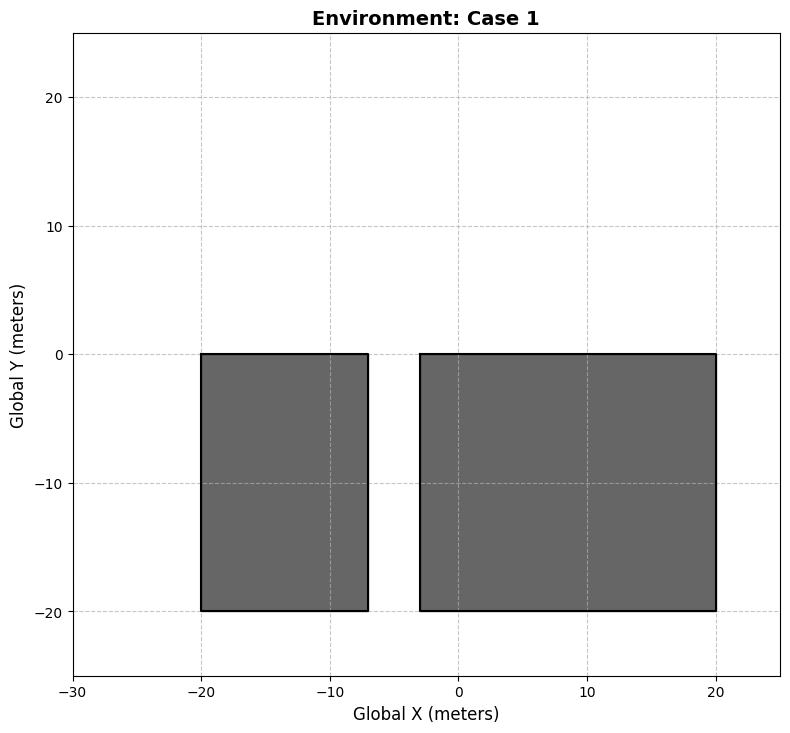

In [ ]:
import matplotlib.pyplot as plt

def plot_obstacle_grid(base_obstacles, title="Obstacle Grid"):

    fig, ax = plt.subplots(figsize=(8, 8))
    
    for obs in base_obstacles:
        x = obs['x']
        y = obs['y']
        
        # Fill the inside of the obstacle
        ax.fill(x, y, color='black', alpha=0.6)
        
        # Draw the solid boundary line
        ax.plot(x, y, color='black', linewidth=1.5)
        
    # Standardize the plot aesthetics
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_aspect('equal') # CRITICAL: Ensures 1m in X looks identical to 1m in Y
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlabel('Global X (meters)', fontsize=12)
    ax.set_ylabel('Global Y (meters)', fontsize=12)
    
    # Set bounds based on the known planning scale of the warehouse
    ax.set_xlim(-30, 25)
    ax.set_ylim(-25, 25)
    
    # Render the plot
    plt.tight_layout()
    plt.show()


plot_obstacle_grid(BASE_OBSTACLES, title="Environment: Case 1")

In [ ]:
import numpy as np
from matplotlib.path import Path


def create_costmap(planning_scale, hybrid_astar, obstacles):
    """
    Generates a binary 2D occupancy grid.
    1 = Obstacle cell, 0 = Free space.
    """
    num_x  = hybrid_astar['num_nodes_x']
    num_y  = hybrid_astar['num_nodes_y']
    res_x  = hybrid_astar['resolution_x']
    res_y  = hybrid_astar['resolution_y']
    xmin   = planning_scale['xmin']
    ymin   = planning_scale['ymin']

    # SANITY
    assert num_x > 0 and num_y > 0, "Grid dimensions must be positive."
    assert res_x > 0 and res_y > 0, "Grid resolutions must be positive."

    costmap = np.zeros((num_x, num_y), dtype=np.uint8)

    # Build grid of all cell centres
    x_coords  = xmin + np.arange(num_x) * res_x
    y_coords  = ymin + np.arange(num_y) * res_y
    xx, yy    = np.meshgrid(x_coords, y_coords, indexing='ij')
    grid_pts  = np.c_[xx.ravel(), yy.ravel()]   # (num_x*num_y, 2)

    total_obstacle_cells = 0
    for i, obs in enumerate(obstacles):
        vertices  = np.column_stack((obs['x'], obs['y']))
        poly_path = Path(vertices)
        inside    = poly_path.contains_points(grid_pts).reshape((num_x, num_y))
        costmap[inside] = 1
        n_cells = int(inside.sum())
        total_obstacle_cells += n_cells
        print(f"[COSTMAP] Obstacle {i}: {n_cells} cells marked occupied.")

    free_pct = 100.0 * (1 - costmap.sum() / costmap.size)
    print(f"[COSTMAP] Grid {num_x}×{num_y} = {costmap.size} cells. "
          f"Occupied: {total_obstacle_cells} ({100-free_pct:.1f}%). "
          f"Free: {free_pct:.1f}%.")

    # SANITY: At least some free space must exist
    assert costmap.sum() < costmap.size, \
        "Costmap is fully occupied — check obstacle definitions or grid bounds."

    return costmap


def convert_2d_config_to_index(x, y, planning_scale, hybrid_astar):
    """
    Converts continuous (x, y) to discrete costmap grid indices.
    Uses np.clip so indices are always valid (no out-of-bounds).
    """
    ind1 = int(np.ceil((x - planning_scale['xmin']) / hybrid_astar['resolution_x']))
    ind2 = int(np.ceil((y - planning_scale['ymin']) / hybrid_astar['resolution_y']))
    ind1 = int(np.clip(ind1, 0, hybrid_astar['num_nodes_x'] - 1))
    ind2 = int(np.clip(ind2, 0, hybrid_astar['num_nodes_y'] - 1))
    return ind1, ind2


def regulate_angle(angle):
    """Maps any angle to [0, 2π)."""
    return angle % (2.0 * np.pi)


def convert_6dim_config_to_index(node, planning_scale, hybrid_astar):
    """
    Converts the full 6-DOF state [x, y, θ1, θ2, θ3, θ4] into a
    discrete 6-tuple for use as a Hybrid A* closed-set key.
    """
    ind1, ind2 = convert_2d_config_to_index(node[0], node[1], planning_scale, hybrid_astar)
    max_th = hybrid_astar['num_nodes_theta'] - 1

    def angle_idx(theta):
        return int(np.clip(
            int(np.ceil(regulate_angle(theta) / hybrid_astar['resolution_theta'])),
            0, max_th
        ))

    return (ind1, ind2,
            angle_idx(node[2]), angle_idx(node[3]),
            angle_idx(node[4]), angle_idx(node[5]))


def _get_rectangle_corners(cx, cy, theta, front_ext, rear_ext, half_width):
    """
    Returns the 4 corners (PX, PY) of a rectangle centred on (cx,cy),
    oriented at angle theta, extending front_ext forward and rear_ext backward.
    """
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    # Front-left, Front-right, Rear-right, Rear-left
    AX = cx + front_ext * cos_t - half_width * sin_t
    AY = cy + front_ext * sin_t + half_width * cos_t
    BX = cx + front_ext * cos_t + half_width * sin_t
    BY = cy + front_ext * sin_t - half_width * cos_t
    CX = cx - rear_ext  * cos_t + half_width * sin_t
    CY = cy - rear_ext  * sin_t - half_width * cos_t
    DX = cx - rear_ext  * cos_t - half_width * sin_t
    DY = cy - rear_ext  * sin_t + half_width * cos_t
    return np.array([AX, BX, CX, DX]), np.array([AY, BY, CY, DY])


def is_tractor_state_valid(x1, y1, theta1, vehicle_geometrics,
                            planning_scale, costmap, hybrid_astar):
    """
    Returns True if the tractor footprint is inside map bounds AND collision-free.

    The tractor's reference point (x1, y1) is the rear-axle centre.
    Front extension = L_tractor_wheelbase + L_tractor_front_hang
    Rear  extension = L_tractor_rear_hang
    """
    front_ext  = vehicle_geometrics['L_tractor_wheelbase'] + vehicle_geometrics['L_tractor_front_hang']
    rear_ext   = vehicle_geometrics['L_tractor_rear_hang']
    half_width = vehicle_geometrics['LHW']

    PX, PY = _get_rectangle_corners(x1, y1, theta1, front_ext, rear_ext, half_width)

    # 1. Boundary check
    if (np.any(PX > planning_scale['xmax']) or np.any(PX < planning_scale['xmin']) or
            np.any(PY > planning_scale['ymax']) or np.any(PY < planning_scale['ymin'])):
        return False

    # 2. Costmap check (each corner)
    for px, py in zip(PX, PY):
        ix, iy = convert_2d_config_to_index(px, py, planning_scale, hybrid_astar)
        if costmap[ix, iy] == 1:
            return False

    return True


def is_trailer_state_valid(x, y, theta, vehicle_geometrics,
                            planning_scale, costmap, hybrid_astar):
    """
    Returns True if a trailer footprint is inside map bounds AND collision-free.

    The trailer's reference point (x, y) is its rear-axle centre.
    Front extension = L_trailer_front_hang  (the part ahead of the axle, toward hitch)
    Rear  extension = L_trailer_rear_hang
    """
    front_ext  = vehicle_geometrics['L_trailer_front_hang']
    rear_ext   = vehicle_geometrics['L_trailer_rear_hang']
    half_width = vehicle_geometrics['LHW']

    PX, PY = _get_rectangle_corners(x, y, theta, front_ext, rear_ext, half_width)

    if (np.any(PX > planning_scale['xmax']) or np.any(PX < planning_scale['xmin']) or
            np.any(PY > planning_scale['ymax']) or np.any(PY < planning_scale['ymin'])):
        return False

    for px, py in zip(PX, PY):
        ix, iy = convert_2d_config_to_index(px, py, planning_scale, hybrid_astar)
        if costmap[ix, iy] == 1:
            return False

    return True


def is_6d_node_valid(x1, y1, theta1, theta2, theta3, theta4,
                     vehicle_geometrics, planning_scale, costmap, hybrid_astar):
    """
    Master validity check for a full 6-DOF tractor-trailer state.

    Steps:
      1. Jackknife check  — relative angle between consecutive units must be < 90 deg
      2. Tractor footprint check
      3. Compute trailer positions via kinematics
      4. Trailer footprint checks
    """
    # 1. Jackknife check
    #    The relevant angles are the RELATIVE articulation angles between consecutive units.
    angles = [theta1, theta2, theta3, theta4]
    for i in range(len(angles) - 1):
        diff = abs(angles[i] - angles[i + 1])
        # Wrap to [0, π]
        diff = min(diff, 2 * np.pi - diff)
        if diff > np.pi / 2:
            return False  # Jackknife detected

    # 2. Tractor collision
    if not is_tractor_state_valid(x1, y1, theta1,
                                   vehicle_geometrics, planning_scale, costmap, hybrid_astar):
        return False

    # 3. Compute trailer axle positions
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(
        x1, y1, theta1, theta2, theta3, theta4, vehicle_geometrics
    )

    # 4. Trailer collisions
    for (tx, ty, tth) in [(x2, y2, theta2), (x3, y3, theta3), (x4, y4, theta4)]:
        if not is_trailer_state_valid(float(tx), float(ty), float(tth),
                                       vehicle_geometrics, planning_scale, costmap, hybrid_astar):
            return False

    return True


COSTMAP = create_costmap(SCALE, ASTAR, BASE_OBSTACLES)

start_valid = is_6d_node_valid(
    BVC['x1_init'], BVC['y1_init'],
    BVC['theta1_init'], BVC['theta2_init'], BVC['theta3_init'], BVC['theta4_init'],
    GEO, SCALE, COSTMAP, ASTAR
)
goal_valid = is_tractor_state_valid(
    BVC['norminal_x1_end'], BVC['norminal_y1_end'],
    BVC['norminal_theta1_end'],
    GEO, SCALE, COSTMAP, ASTAR
)

print(f"\n[BLOCK 2 SANITY] Start state valid  : {'✓ YES' if start_valid else '✗ NO — START IS IN COLLISION!'}")
print(f"[BLOCK 2 SANITY] Goal  state valid  : {'✓ YES' if goal_valid  else '✗ NO — GOAL  IS IN COLLISION!'}")

if not start_valid:
    raise RuntimeError("Start configuration is in collision or out of bounds. "
                       "Check BVC start coordinates vs obstacle layout.")
if not goal_valid:
    raise RuntimeError("Goal configuration is in collision or out of bounds. "
                       "Check BVC goal coordinates vs obstacle layout.")

print("[BLOCK 2 COMPLETE] Costmap and collision checkers ready.\n")

[COSTMAP] Obstacle 0: 11571 cells marked occupied.
[COSTMAP] Obstacle 1: 20349 cells marked occupied.
[COSTMAP] Grid 335×268 = 89780 cells. Occupied: 31920 (35.6%). Free: 64.4%.

[BLOCK 2 SANITY] Start state valid  : ✓ YES
[BLOCK 2 SANITY] Goal  state valid  : ✓ YES
[BLOCK 2 COMPLETE] Costmap and collision checkers ready.



In [ ]:
import numpy as np
import heapq
import time


_old = ASTAR['terminal_xy_neiborhood']
ASTAR['terminal_xy_neiborhood'] = 1.5
print(f"[BUG 1 FIX] terminal_xy_neiborhood: {_old} m  →  {ASTAR['terminal_xy_neiborhood']} m")


def calculate_h_2d(node_index, goal_idx):
    return abs(node_index[0] - goal_idx[0]) + abs(node_index[1] - goal_idx[1])


def generate_astar_path(begin_config, end_config, costmap, planning_scale, hybrid_astar):
    """Standard 2-D A*.  Returns approximate arc-length in metres, or 0 on failure."""
    goal_idx = convert_2d_config_to_index(end_config[0], end_config[1], planning_scale, hybrid_astar)
    init_idx  = convert_2d_config_to_index(begin_config[0], begin_config[1], planning_scale, hybrid_astar)
    if costmap[init_idx[0], init_idx[1]] == 1 or costmap[goal_idx[0], goal_idx[1]] == 1:
        return 0.0

    num_x, num_y = hybrid_astar['num_nodes_x'], hybrid_astar['num_nodes_y']
    closed_set   = set()
    open_heap    = []
    heapq.heappush(open_heap, (calculate_h_2d(init_idx, goal_idx), 0.0, init_idx))
    g_scores     = {init_idx: 0.0}
    neighbours   = [(-1,1,1.414),(-1,0,1.),(-1,-1,1.414),(0,1,1.),(0,-1,1.),(1,1,1.414),(1,0,1.),(1,-1,1.414)]

    for _ in range(500):
        if not open_heap:
            break
        _, cg, ci = heapq.heappop(open_heap)
        if ci == goal_idx:
            return cg * hybrid_astar['resolution_x']
        if ci in closed_set:
            continue
        closed_set.add(ci)
        for dx, dy, mc in neighbours:
            nb = (ci[0]+dx, ci[1]+dy)
            if not (0 <= nb[0] < num_x and 0 <= nb[1] < num_y):
                continue
            if costmap[nb[0], nb[1]] == 1:
                continue
            tg = cg + mc
            if nb not in g_scores or tg < g_scores[nb]:
                g_scores[nb] = tg
                heapq.heappush(open_heap, (tg + calculate_h_2d(nb, goal_idx), tg, nb))
    return 0.0


def calculate_h(node_6d, bvc, costmap, planning_scale, hybrid_astar):
    end_xy    = [bvc['norminal_x1_end'], bvc['norminal_y1_end']]
    h_holo    = generate_astar_path(node_6d[:2], end_xy, costmap, planning_scale, hybrid_astar)
    h_dist    = np.hypot(end_xy[0]-node_6d[0], end_xy[1]-node_6d[1])
    ang_err   = abs(node_6d[2]-bvc['norminal_theta1_end'])
    ang_err   = min(ang_err, 2*np.pi - ang_err)
    return hybrid_astar['multiplier_H'] * max(h_dist + ang_err*2.0, h_holo)


def simulate_forward(node_6d, v, phy, vehicle_geometrics):
    """
    Euler integration: position updated with theta at the START of each sub-step,
    then heading is updated.  (Original code wrongly used theta_next for position.)
    """
    x0, y0, th1_0, th2_0, th3_0, th4_0 = node_6d
    L_wb = vehicle_geometrics['L_tractor_wheelbase']
    Nfe  = 20
    dt   = 1.0 / Nfe
    phy  = float(np.clip(phy, -np.pi/2+1e-6, np.pi/2-1e-6))

    xt  = np.empty(Nfe); xt[0]  = x0
    yt  = np.empty(Nfe); yt[0]  = y0
    th1 = np.empty(Nfe); th1[0] = th1_0

    for i in range(1, Nfe):
        tc     = th1[i-1]
        xt[i]  = xt[i-1]  + dt * np.cos(tc) * v   # ← use theta_current
        yt[i]  = yt[i-1]  + dt * np.sin(tc) * v
        th1[i] = tc        + dt * np.tan(phy) * v / L_wb

    M  = vehicle_geometrics['M']
    L  = vehicle_geometrics['L']
    th2 = np.empty(Nfe); th2[0] = th2_0
    th3 = np.empty(Nfe); th3[0] = th3_0
    th4 = np.empty(Nfe); th4[0] = th4_0

    for i in range(1, Nfe):
        dx   = xt[i]-xt[i-1]; dy = yt[i]-yt[i-1]
        tp   = th1[i-1]
        cp, sp = np.cos(tp), np.sin(tp)
        ds1  = dx/(cp+1e-9) if abs(cp)>=abs(sp) else dy/(sp+1e-9)
        dth1 = th1[i]-th1[i-1]

        a1      = tp - th2[i-1]
        dth2    = (ds1*np.sin(a1) - M[0]*np.cos(a1)*dth1) / L[1]
        th2[i]  = th2[i-1] + dth2
        ds2     = ds1*np.cos(a1) + M[0]*np.sin(a1)*dth1

        a2      = th2[i-1]-th3[i-1]
        dth3    = (ds2*np.sin(a2) - M[1]*np.cos(a2)*dth2) / L[2]
        th3[i]  = th3[i-1] + dth3
        ds3     = ds2*np.cos(a2) + M[1]*np.sin(a2)*dth2

        a3      = th3[i-1]-th4[i-1]
        dth4    = (ds3*np.sin(a3) - M[2]*np.cos(a3)*dth3) / L[3]
        th4[i]  = th4[i-1] + dth4

    return xt, yt, th1, th2, th3, th4


def plan_hybrid_astar_path(bvc, hybrid_astar, vehicle_physics, vehicle_geometrics,
                            planning_scale, costmap):
    print("[HYBRID A*] Starting Search (Grid Only, Delta-Steering Enabled)...")
    t0 = time.time()

    init_6d   = (bvc['x1_init'], bvc['y1_init'],
                 bvc['theta1_init'], bvc['theta2_init'],
                 bvc['theta3_init'], bvc['theta4_init'])
    init_h    = calculate_h(init_6d, bvc, costmap, planning_scale, hybrid_astar)
    init_hist = ([init_6d[0]], [init_6d[1]], [init_6d[2]],
                 [init_6d[3]], [init_6d[4]], [init_6d[5]])

    ctr = 0
    heap = []

    heapq.heappush(heap, (init_h, ctr, 0.0, init_6d, init_hist, 1.0, 0.0))
    
    closed  = set()
    best_h = init_h
    best_hist = init_hist   

    p_max = vehicle_physics['phy_max']
    expns = [
        ( 1.0, -p_max), ( 1.0, -p_max/2.0), ( 1.0,  0.0), ( 1.0,  p_max/2.0), ( 1.0,  p_max),
        (-1.0, -p_max), (-1.0, -p_max/2.0), (-1.0,  0.0), (-1.0,  p_max/2.0), (-1.0,  p_max),
    ]

    for it in range(1, hybrid_astar['max_iter'] + 1):
        if not heap:
            print(f"[HYBRID A*] Heap empty at iter {it-1}.")
            break

        f, _tb, g, cur6d, hist, prev_v, prev_phy = heapq.heappop(heap)

        h_now = f - g
        if h_now < best_h:
            best_h = h_now
            best_hist = hist

        gidx = convert_6dim_config_to_index(cur6d, planning_scale, hybrid_astar)
        if gidx in closed:
            continue
        closed.add(gidx)

        dist_goal = np.hypot(cur6d[0]-bvc['norminal_x1_end'],
                             cur6d[1]-bvc['norminal_y1_end'])
        
        if dist_goal < hybrid_astar['terminal_xy_neiborhood']:
            ae = min(abs(cur6d[2]-bvc['norminal_theta1_end']),
                     2*np.pi - abs(cur6d[2]-bvc['norminal_theta1_end']))
            print(f"[HYBRID A*] ✓  iter={it}  dist={dist_goal:.3f} m  "
                  f"angle_err={np.degrees(ae):.1f}°  |closed|={len(closed)}  "
                  f"time={time.time()-t0:.2f} s")
            return hist

        for v, phy in expns:
            xt, yt, t1, t2, t3, t4 = simulate_forward(cur6d, v, phy, vehicle_geometrics)
            ch = (float(xt[-1]), float(yt[-1]), float(t1[-1]),
                  float(t2[-1]), float(t3[-1]), float(t4[-1]))
                  
            if not is_6d_node_valid(ch[0], ch[1], ch[2], ch[3], ch[4], ch[5],
                                    vehicle_geometrics, planning_scale, costmap, hybrid_astar):
                continue

            mc = 1.0
            if v < 0: 
                mc *= hybrid_astar.get('penalty_multiplier_for_reversing', 2.0)
            
            delta_v = abs(v - prev_v)
            delta_phy = abs(phy - prev_phy)
            direction_penalty = hybrid_astar.get('penalty_multiplier_for_drastic_direction_change', 5.0) * (delta_v + delta_phy)
            
            cg = g + mc + direction_penalty
            ch_h = calculate_h(ch, bvc, costmap, planning_scale, hybrid_astar)
            
            new_hist = (hist[0]+xt.tolist(), hist[1]+yt.tolist(),
                        hist[2]+t1.tolist(), hist[3]+t2.tolist(),
                        hist[4]+t3.tolist(), hist[5]+t4.tolist())
            ctr += 1
            
            heapq.heappush(heap, (cg+ch_h, ctr, cg, ch, new_hist, v, phy))

        if it % 1000 == 0:
            print(f"[HYBRID A*] iter {it:4d}/{hybrid_astar['max_iter']} | "
                  f"closed={len(closed):5d} | open={len(heap):6d} | "
                  f"best_dist={np.hypot(cur6d[0]-bvc['norminal_x1_end'], cur6d[1]-bvc['norminal_y1_end']):.2f} m")

    print(f"[HYBRID A*] ✗ Max iterations. Returning best node (h={best_h:.3f}). "
          f"time={time.time()-t0:.1f} s")
    return best_hist

def _sanity_simulate():
    print("[SANITY simulate_forward] …")
    z = (0.,0.,0.,0.,0.,0.)
    x,y,th1,*_ = simulate_forward(z, 0., 0., GEO)
    assert np.allclose(x,0,atol=1e-10) and np.allclose(y,0,atol=1e-10), "zero-v: must stay put"
    print("  [1/3] zero velocity → stationary ✓")
    x,y,th1,*_ = simulate_forward(z, 1., 0., GEO)
    assert np.all(np.abs(y)<1e-10) and np.all(np.diff(x)>0), "straight: must go along +X"
    print("  [2/3] straight → +X motion ✓")
    x,y,th1,*_ = simulate_forward(z, 1., PHYS['phy_max'], GEO)
    assert th1[-1]>0 and y[-1]>0, "left turn: heading and y must be positive"
    print(f"  [3/3] left turn → heading={np.degrees(th1[-1]):.2f}°, y={y[-1]:.4f} ✓")
    print("[SANITY simulate_forward] all passed.\n")

_sanity_simulate()

PATH_HISTORY = plan_hybrid_astar_path(BVC, ASTAR, PHYS, GEO, SCALE, COSTMAP)

print("\n[BLOCK 3 SANITY]")
px, py = PATH_HISTORY[0], PATH_HISTORY[1]
assert len(px) > 1
arc_len  = float(np.sum(np.hypot(np.diff(px), np.diff(py))))
end_dist = np.hypot(px[-1]-BVC['norminal_x1_end'], py[-1]-BVC['norminal_y1_end'])
print(f"  Points     : {len(px)}")
print(f"  Arc length : {arc_len:.2f} m")
print(f"  Start      : ({px[0]:.2f}, {py[0]:.2f})")
print(f"  End        : ({px[-1]:.2f}, {py[-1]:.2f})")
print(f"  Goal       : ({BVC['norminal_x1_end']:.2f}, {BVC['norminal_y1_end']:.2f})")
print(f"  End→goal   : {end_dist:.2f} m  "
      f"({'✓' if end_dist<=1.5 else '⚠ A* hit max_iter before goal'})")
print("[BLOCK 3 COMPLETE]\n")

[BUG 1 FIX] terminal_xy_neiborhood: 5.0 m  →  1.5 m
[SANITY simulate_forward] …
  [1/3] zero velocity → stationary ✓
  [2/3] straight → +X motion ✓
  [3/3] left turn → heading=30.56°, y=0.2347 ✓
[SANITY simulate_forward] all passed.

[HYBRID A*] Starting Search (Grid Only, Delta-Steering Enabled)...
[HYBRID A*] iter 1000/10000 | closed=  968 | open=  5925 | best_dist=21.94 m
[HYBRID A*] iter 2000/10000 | closed= 1924 | open= 11429 | best_dist=21.01 m
[HYBRID A*] iter 3000/10000 | closed= 2881 | open= 16644 | best_dist=16.54 m
[HYBRID A*] iter 4000/10000 | closed= 3810 | open= 21758 | best_dist=22.97 m
[HYBRID A*] iter 5000/10000 | closed= 4755 | open= 27127 | best_dist=21.34 m
[HYBRID A*] iter 6000/10000 | closed= 5688 | open= 32487 | best_dist=18.09 m
[HYBRID A*] iter 7000/10000 | closed= 6622 | open= 37822 | best_dist=21.40 m
[HYBRID A*] iter 8000/10000 | closed= 7546 | open= 43188 | best_dist=19.98 m
[HYBRID A*] iter 9000/10000 | closed= 8483 | open= 48678 | best_dist=19.40 m
[HYBRI

In [34]:
import casadi as ca
import numpy as np

def create_casadi_kinematic_model(vehicle_geometrics):
    """
    Creates a CasADi function representing the continuous-time dynamics 
    of the tractor and 3 off-axle trailers.
    """
    # 1. State Variables
    x   = ca.SX.sym('x')
    y   = ca.SX.sym('y')
    th1 = ca.SX.sym('th1')
    th2 = ca.SX.sym('th2')
    th3 = ca.SX.sym('th3')
    th4 = ca.SX.sym('th4')
    states = ca.vertcat(x, y, th1, th2, th3, th4)
    
    # 2. Control Variables
    v   = ca.SX.sym('v')     # Tractor velocity
    phy = ca.SX.sym('phy')   # Tractor steering angle
    controls = ca.vertcat(v, phy)
    
    # Geometrics
    L_wb = vehicle_geometrics['L_tractor_wheelbase']
    M = vehicle_geometrics['M']
    L = vehicle_geometrics['L']
    
    # 3. Continuous Kinematic Differential Equations
    # Tractor
    dx = v * ca.cos(th1)
    dy = v * ca.sin(th1)
    dth1 = v * ca.tan(phy) / L_wb
    
    # Trailer 1 (Off-axle)
    v2 = v * ca.cos(th1 - th2) + M[0] * ca.sin(th1 - th2) * dth1
    dth2 = (v * ca.sin(th1 - th2) - M[0] * ca.cos(th1 - th2) * dth1) / L[1]
    
    # Trailer 2 (Off-axle)
    v3 = v2 * ca.cos(th2 - th3) + M[1] * ca.sin(th2 - th3) * dth2
    dth3 = (v2 * ca.sin(th2 - th3) - M[1] * ca.cos(th2 - th3) * dth2) / L[2]
    
    # Trailer 3 (Off-axle)
    dth4 = (v3 * ca.sin(th3 - th4) - M[2] * ca.cos(th3 - th4) * dth3) / L[3]
    
    rhs = ca.vertcat(dx, dy, dth1, dth2, dth3, dth4)
    
    # Return a CasADi function: x_dot = f(x, u)
    return ca.Function('f', [states, controls], [rhs], ['x', 'u'], ['rhs'])

casadi_f = create_casadi_kinematic_model(GEO)

In [ ]:
# Unpack Hybrid A* result
ref_x   = np.array(PATH_HISTORY[0])
ref_y   = np.array(PATH_HISTORY[1])
ref_th1 = np.array(PATH_HISTORY[2])
ref_th2 = np.array(PATH_HISTORY[3])
ref_th3 = np.array(PATH_HISTORY[4])
ref_th4 = np.array(PATH_HISTORY[5])

N = len(ref_x)
state_dim = 6
control_dim = 2

X_ref = np.vstack((ref_x, ref_y, ref_th1, ref_th2, ref_th3, ref_th4))

total_dist = float(np.sum(np.hypot(np.diff(ref_x), np.diff(ref_y))))
nominal_time = total_dist / (PHYS['v_max'] * 0.8) # assume average speed is 80% of max
dt = nominal_time / (N - 1)

In [36]:
print("\n[STAGE 1] Formulating Subproblem 1 (Smoothing A* path)...")

opti1 = ca.Opti()

# Decision Variables
X1 = opti1.variable(state_dim, N)
U1 = opti1.variable(control_dim, N-1)

# Objective Function Weights
W_ref   = 10.0   # Weight for matching A* path
W_ctrl  = 1.0    # Weight for minimizing control effort
W_jerk  = 5.0    # Weight for smooth controls (control rate)
W_kin   = 100.0  # Soft penalty for kinematic violations

obj = 0

for k in range(N-1):
    # 1. Tracking cost (Stay close to A* path)
    err = X1[:, k] - X_ref[:, k]
    obj += W_ref * ca.sumsqr(err[:2]) # Heavily weight X, Y tracking
    obj += (W_ref * 0.1) * ca.sumsqr(err[2:]) # Lighter weight on angles
    
    # 2. Control effort cost
    obj += W_ctrl * ca.sumsqr(U1[:, k])
    
    # 3. Smoothness cost (minimize dU)
    if k < N-2:
        obj += W_jerk * ca.sumsqr(U1[:, k+1] - U1[:, k])
        
    # 4. Soft Kinematic Constraints (Euler Integration)
    x_next_euler = X1[:, k] + casadi_f(X1[:, k], U1[:, k]) * dt
    kin_violation = X1[:, k+1] - x_next_euler
    obj += W_kin * ca.sumsqr(kin_violation)

# Tracking cost for final node
obj += W_ref * ca.sumsqr(X1[:, N-1] - X_ref[:, N-1])

opti1.minimize(obj)

# Control Limits (Hard constraints on physics are allowed here to keep inputs realistic)
opti1.subject_to(opti1.bounded(-PHYS['v_max'], U1[0, :], PHYS['v_max']))
opti1.subject_to(opti1.bounded(-PHYS['phy_max'], U1[1, :], PHYS['phy_max']))

# Initial Guess (Seed the solver with the Hybrid A* path)
opti1.set_initial(X1, X_ref)
opti1.set_initial(U1, np.zeros((control_dim, N-1)))

# Solver Setup
p_opts = {"expand": True, "print_time": False}
s_opts = {"max_iter": 300, "print_level": 0, "tol": 1e-4}
opti1.solver("ipopt", p_opts, s_opts)

# Solve Stage 1
sol1 = opti1.solve()
X_stage1_opt = sol1.value(X1)
U_stage1_opt = sol1.value(U1)
print(f"[STAGE 1] Optimum found. Objective value: {sol1.value(obj):.2f}")


[STAGE 1] Formulating Subproblem 1 (Smoothing A* path)...
[STAGE 1] Optimum found. Objective value: 85.24


In [ ]:
print("\n[STAGE 2] Formulating Subproblem 2 (Boundary & Kinematics)...")

opti2 = ca.Opti()

X2 = opti2.variable(state_dim, N)
U2 = opti2.variable(control_dim, N-1)

obj2 = 0
W_track_s1 = 1.0 
W_dU = 10.0      

for k in range(N-1):
    obj2 += W_track_s1 * ca.sumsqr(X2[:, k] - X_stage1_opt[:, k])
    if k < N-2:
        obj2 += W_dU * ca.sumsqr(U2[:, k+1] - U2[:, k])
        
    x_k = X2[:, k]
    u_k = U2[:, k]
    
    k1 = casadi_f(x_k, u_k)
    k2 = casadi_f(x_k + dt/2 * k1, u_k)
    k3 = casadi_f(x_k + dt/2 * k2, u_k)
    k4 = casadi_f(x_k + dt * k3, u_k)
    x_next_rk4 = x_k + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
    opti2.subject_to(X2[:, k+1] == x_next_rk4)

opti2.minimize(obj2)

start_state = [BVC['x1_init'], BVC['y1_init'], BVC['theta1_init'], 
               BVC['theta2_init'], BVC['theta3_init'], BVC['theta4_init']]
goal_state = [BVC['norminal_x1_end'], BVC['norminal_y1_end'], BVC['norminal_theta1_end'], 
              BVC['norminal_theta2_end'], BVC['norminal_theta3_end'], BVC['norminal_theta4_end']]

opti2.subject_to(X2[:, 0] == start_state)
opti2.subject_to(X2[:, -1] == goal_state)

# Control Limits
opti2.subject_to(opti2.bounded(-PHYS['v_max'], U2[0, :], PHYS['v_max']))
opti2.subject_to(opti2.bounded(-PHYS['phy_max'], U2[1, :], PHYS['phy_max']))

# Initial Guess (Seed with Stage 1's optimal solution)
opti2.set_initial(X2, X_stage1_opt)
opti2.set_initial(U2, U_stage1_opt)

# Solver Setup
s_opts2 = {"max_iter": 500, "print_level": 5, "acceptable_tol": 1e-3} # Print level 5 to watch IPOPT work
opti2.solver("ipopt", p_opts, s_opts2)

try:
    sol2 = opti2.solve()
    X_final = sol2.value(X2)
    U_final = sol2.value(U2)
    print(f"\n[STAGE 2] Success! Kinematically feasible path generated.")
except Exception as e:
    print(f"\n[STAGE 2] Optimizer failed. Extracting best-effort solution.")
    X_final = opti2.debug.value(X2)
    U_final = opti2.debug.value(U2)


[STAGE 2] Formulating Subproblem 2 (Boundary & Kinematics)...
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    13452
Number of nonzeros in inequality constraint Jacobian.:      840
Number of nonzeros in Lagrangian Hessian.............:    10498

Total number of variables............................:     3366
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2532
Total number of inequality constraints...............:      840
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:      840
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.433247

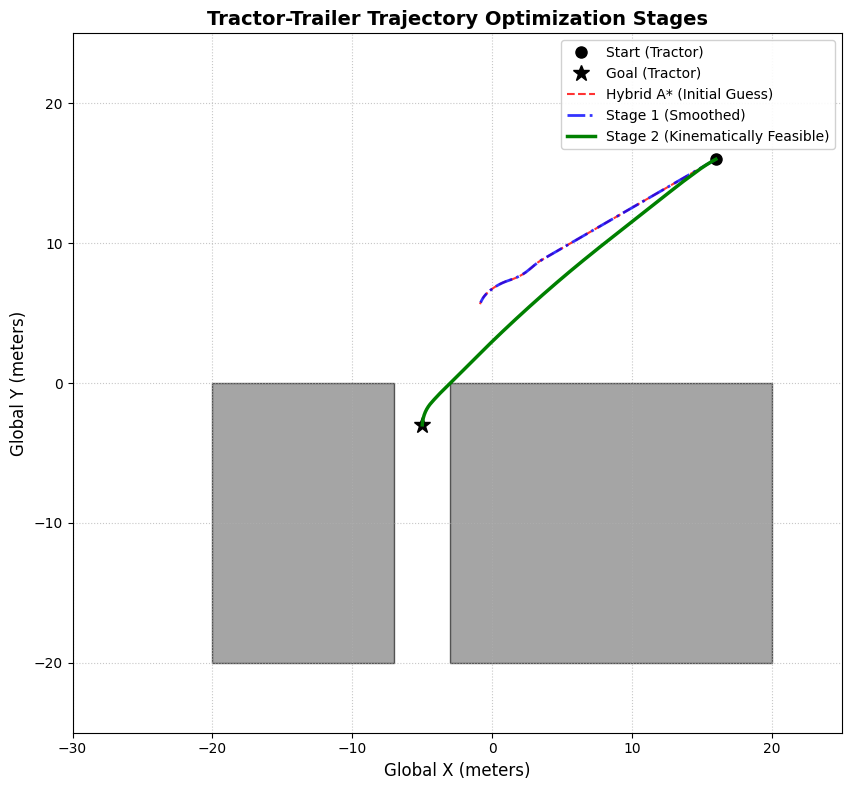

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trajectory_comparison(obstacles, bvc, path_astar=None, path_stage1=None, path_stage2=None):

    fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Plot Obstacles
    for obs in obstacles:
        ax.fill(obs['x'], obs['y'], color='dimgray', alpha=0.6, edgecolor='black')

    # 2. Plot Start and Goal configurations (Tractor Rear Axle)
    ax.plot(bvc['x1_init'], bvc['y1_init'], 'ko', markersize=8, label='Start (Tractor)')
    ax.plot(bvc['norminal_x1_end'], bvc['norminal_y1_end'], 'k*', markersize=12, label='Goal (Tractor)')

    # 3. Plot the Rough Path derived by Hybrid A*
    if path_astar is not None:
        # path_astar[0] is X, path_astar[1] is Y
        ax.plot(path_astar[0], path_astar[1], 'r--', linewidth=1.5, alpha=0.8, label='Hybrid A* (Initial Guess)')

    # 4. Plot Stage 1: Smoothed Path (Ignored Kinematics/Boundaries)
    if path_stage1 is not None:
        # CasADi outputs are usually (state_dim, N), so row 0 is X, row 1 is Y
        ax.plot(path_stage1[0, :], path_stage1[1, :], 'b-.', linewidth=2.0, alpha=0.8, label='Stage 1 (Smoothed)')

    # 5. Plot Stage 2: Kinematically Feasible Path satisfying Boundaries
    if path_stage2 is not None:
        ax.plot(path_stage2[0, :], path_stage2[1, :], 'g-', linewidth=2.5, label='Stage 2 (Kinematically Feasible)')

    # Formatting and aesthetics
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.set_xlabel('Global X (meters)', fontsize=12)
    ax.set_ylabel('Global Y (meters)', fontsize=12)
    ax.set_title('Tractor-Trailer Trajectory Optimization Stages', fontsize=14, fontweight='bold')
    
    # Set bounds based on standard warehouse planning scale
    ax.set_xlim(-30, 25)
    ax.set_ylim(-25, 25)
    
    ax.legend(loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()


plot_trajectory_comparison(BASE_OBSTACLES, BVC, PATH_HISTORY, X_stage1_opt, X_final)

Generating Hybrid A* visualization...


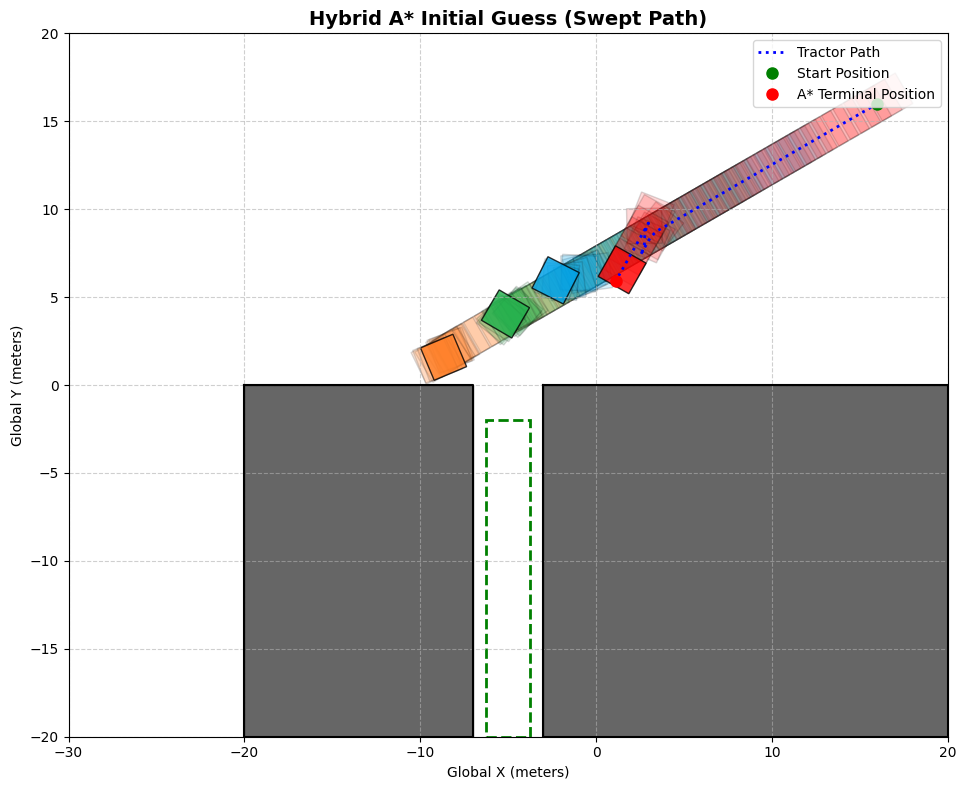

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_vehicle_state(ax, x1, y1, th1, th2, th3, th4, geo, color_alpha=0.3):
    """Draws the tractor and 3 trailers at a specific state on the given axes."""
    LHW = geo['LHW']
    
    L_front = geo['L_tractor_front_hang']
    L_wb = geo['L_tractor_wheelbase']
    L_rear = geo['L_tractor_rear_hang']
    front_ext = L_front + L_wb
    
    tractor_poly = np.array([
        [x1 + front_ext*np.cos(th1) - LHW*np.sin(th1), y1 + front_ext*np.sin(th1) + LHW*np.cos(th1)],
        [x1 + front_ext*np.cos(th1) + LHW*np.sin(th1), y1 + front_ext*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) + LHW*np.sin(th1), y1 - L_rear*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) - LHW*np.sin(th1), y1 - L_rear*np.sin(th1) + LHW*np.cos(th1)]
    ])
    ax.add_patch(patches.Polygon(tractor_poly, closed=True, facecolor='red', edgecolor='black', alpha=color_alpha))


    M, L = geo['M'], geo['L']
    x2 = x1 - M[0]*np.cos(th1) - L[1]*np.cos(th2)
    y2 = y1 - M[0]*np.sin(th1) - L[1]*np.sin(th2)
    x3 = x2 - M[1]*np.cos(th2) - L[2]*np.cos(th3)
    y3 = y2 - M[1]*np.sin(th2) - L[2]*np.sin(th3)
    x4 = x3 - M[2]*np.cos(th3) - L[3]*np.cos(th4)
    y4 = y3 - M[2]*np.sin(th3) - L[3]*np.sin(th4)
    
    trailer_states = [(x2, y2, th2), (x3, y3, th3), (x4, y4, th4)]
    t_front, t_rear = geo['L_trailer_front_hang'], geo['L_trailer_rear_hang']
    colors = ['#00A2E8', '#22B14C', '#FF7F27'] # Cyan, Green, Orange
    
    for i, (tx, ty, t_th) in enumerate(trailer_states):
        trailer_poly = np.array([
            [tx + t_front*np.cos(t_th) - LHW*np.sin(t_th), ty + t_front*np.sin(t_th) + LHW*np.cos(t_th)],
            [tx + t_front*np.cos(t_th) + LHW*np.sin(t_th), ty + t_front*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) + LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) - LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) + LHW*np.cos(t_th)]
        ])
        ax.add_patch(patches.Polygon(trailer_poly, closed=True, facecolor=colors[i], edgecolor='black', alpha=color_alpha))

def plot_hybrid_astar_trajectory(path_history, obstacles, bvc, scale, geo, sample_step=15):
    """
    Visualizes the Hybrid A* path history on the warehouse grid.
    
    Args:
        path_history (tuple): The 6-element tuple of lists (x, y, th1, th2, th3, th4) returned by A*.
        sample_step (int): Draws the vehicle footprints every Nth point to avoid clutter.
    """
    print("Generating Hybrid A* visualization...")
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Setup Canvas
    ax.set_xlim(scale['xmin'], scale['xmax'])
    ax.set_ylim(scale['ymin'], scale['ymax'])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title("Hybrid A* Initial Guess (Swept Path)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Global X (meters)")
    ax.set_ylabel("Global Y (meters)")

    # 2. Draw Obstacles
    for obs in obstacles:
        ax.fill(obs['x'], obs['y'], color='black', alpha=0.6)
        ax.plot(obs['x'], obs['y'], color='black', linewidth=1.5)

    # 3. Draw Goal Region (Green Dashed Box)
    goal_box = patches.Rectangle(
        (bvc['xc_end'] - bvc['x_end_half_width'], bvc['yc_end'] - bvc['y_end_half_width']),
        bvc['x_end_half_width'] * 2, bvc['y_end_half_width'] * 2,
        linewidth=2, edgecolor='green', facecolor='none', linestyle='--'
    )
    ax.add_patch(goal_box)

    x_traj, y_traj = path_history[0], path_history[1]
    th1, th2 = path_history[2], path_history[3]
    th3, th4 = path_history[4], path_history[5]
    
    total_points = len(x_traj)
    
    ax.plot(x_traj, y_traj, color='blue', linewidth=2, linestyle=':', label="Tractor Path")
    

    for i in range(0, total_points, sample_step):
        draw_vehicle_state(ax, x_traj[i], y_traj[i], th1[i], th2[i], th3[i], th4[i], geo, color_alpha=0.15)
        
    draw_vehicle_state(ax, x_traj[-1], y_traj[-1], th1[-1], th2[-1], th3[-1], th4[-1], geo, color_alpha=0.8)

    ax.plot(x_traj[0], y_traj[0], 'go', markersize=8, label='Start Position')
    ax.plot(x_traj[-1], y_traj[-1], 'ro', markersize=8, label='A* Terminal Position')

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_hybrid_astar_trajectory(PATH_HISTORY, BASE_OBSTACLES, BVC, SCALE, GEO, sample_step=15)


In [ ]:
import casadi as ca
import numpy as np
from scipy.interpolate import interp1d
import time

def resample_config(path_input, num_points=101):
    """Resamples the path to exactly num_points arc-length-uniform points."""
    # Safely unpack if input is a 2D numpy array (6, N) from CasADi
    if isinstance(path_input, np.ndarray) and path_input.shape[0] == 6:
        arrays = [np.array(path_input[i, :], dtype=float) for i in range(6)]
    else:
        arrays = [np.array(a, dtype=float) for a in path_input]
        
    x, y, th1, th2, th3, th4 = arrays
    n_raw = len(x)

    dists = np.hypot(np.diff(x), np.diff(y))
    keep  = np.concatenate(([True], dists > 1e-9))
    x, y, th1, th2, th3, th4 = (a[keep] for a in [x, y, th1, th2, th3, th4])
    n_dd = int(keep.sum())

    s = np.concatenate(([0.], np.cumsum(np.hypot(np.diff(x), np.diff(y)))))
    s_n = s / s[-1]
    s_tgt = np.linspace(0., 1., num_points)

    result = {
        'x':   interp1d(s_n, x,             kind='linear')(s_tgt),
        'y':   interp1d(s_n, y,             kind='linear')(s_tgt),
        'th1': interp1d(s_n, np.unwrap(th1), kind='linear')(s_tgt),
        'th2': interp1d(s_n, np.unwrap(th2), kind='linear')(s_tgt),
        'th3': interp1d(s_n, np.unwrap(th3), kind='linear')(s_tgt),
        'th4': interp1d(s_n, np.unwrap(th4), kind='linear')(s_tgt),
    }
    return result, float(s[-1])

def scale_obstacles(base_obstacles, gamma):
    gamma = float(np.clip(gamma, 0., 1.))
    scaled = []
    for obs in base_obstacles:
        xa, ya = np.array(obs['x'], dtype=float), np.array(obs['y'], dtype=float)
        cx, cy = float(np.mean(xa[:-1])), float(np.mean(ya[:-1]))
        scaled.append({'x': (cx + (xa-cx)*gamma).tolist(),
                       'y': (cy + (ya-cy)*gamma).tolist()})
    return scaled

def compute_halfplanes(obs_x, obs_y):
    vx = list(obs_x[:-1])
    vy = list(obs_y[:-1])
    n  = len(vx)
    area2 = sum(vx[i]*vy[(i+1)%n] - vx[(i+1)%n]*vy[i] for i in range(n))
    if area2 < 0:
        vx, vy = vx[::-1], vy[::-1]
    planes = []
    for i in range(n):
        j  = (i+1) % n
        dx, dy = vx[j]-vx[i], vy[j]-vy[i]
        L  = np.hypot(dx, dy)
        if L < 1e-9: continue
        nx, ny = dy/L, -dx/L
        offset = nx*vx[i] + ny*vy[i]
        planes.append((float(nx), float(ny), float(offset)))
    return planes

def _smooth_outside(px, py, halfplanes, margin, scale=8.0):
    terms = [ca.exp(ca.fmin(scale*(nx*px + ny*py - off), 50.))
             for nx, ny, off in halfplanes]
    return ca.log(sum(terms)) / scale - margin

def solve_pcoc_nlp(initial_guess, halfplanes_per_obstacle, bvc, vehicle_physics, vehicle_geometrics, dt_fixed):
    N   = len(initial_guess['x']) - 1
    M   = vehicle_geometrics['M']
    L   = vehicle_geometrics['L']
    LHW = vehicle_geometrics['LHW']
    L_wb = vehicle_geometrics['L_tractor_wheelbase']
    OBS_MARGIN = LHW + 0.35

    opti = ca.Opti()
    X = opti.variable(6, N+1)
    U = opti.variable(2, N)

    cost = 0
    for k in range(N):
        cost += ca.sumsqr(U[0, k]) * 1.0
        cost += ca.sumsqr(U[1, k]) * 5.0
        
        # Penalize large angles between consecutive trailers to keep them straight
        cost += ca.sumsqr(X[2, k] - X[3, k]) * 0.5 
        cost += ca.sumsqr(X[3, k] - X[4, k]) * 0.5
        cost += ca.sumsqr(X[4, k] - X[5, k]) * 0.5
        
        if k < N-1:
            cost += ca.sumsqr(U[0, k+1] - U[0, k]) * 3.0
            cost += ca.sumsqr(U[1, k+1] - U[1, k]) * 3.0
                
    opti.minimize(cost)

    for k in range(N):
        v = U[0, k]
        phi = U[1, k]
        th1_k = X[2, k]
        
        opti.subject_to(X[0, k+1] == X[0, k] + v * ca.cos(th1_k) * dt_fixed)
        opti.subject_to(X[1, k+1] == X[1, k] + v * ca.sin(th1_k) * dt_fixed)
        th1_kp1 = th1_k + (v * ca.tan(phi) / L_wb) * dt_fixed
        opti.subject_to(X[2, k+1] == th1_kp1)

        ds1 = v * dt_fixed
        a1 = th1_k - X[3, k]
        dth1 = th1_kp1 - th1_k
        dth2 = (ds1 * ca.sin(a1) - M[0] * ca.cos(a1) * dth1) / L[1]
        opti.subject_to(X[3, k+1] == X[3, k] + dth2)

        ds2 = ds1 * ca.cos(a1) + M[0] * ca.sin(a1) * dth1
        a2 = X[3, k] - X[4, k]
        dth3 = (ds2 * ca.sin(a2) - M[1] * ca.cos(a2) * dth2) / L[2]
        opti.subject_to(X[4, k+1] == X[4, k] + dth3)

        ds3 = ds2 * ca.cos(a2) + M[1] * ca.sin(a2) * dth2
        a3 = X[4, k] - X[5, k]
        dth4 = (ds3 * ca.sin(a3) - M[2] * ca.cos(a3) * dth3) / L[3]
        opti.subject_to(X[5, k+1] == X[5, k] + dth4)
    MAX_ART = 1.48 
    for k in range(N+1):
        opti.subject_to(opti.bounded(-MAX_ART, X[2, k] - X[3, k], MAX_ART))
        opti.subject_to(opti.bounded(-MAX_ART, X[3, k] - X[4, k], MAX_ART))
        opti.subject_to(opti.bounded(-MAX_ART, X[4, k] - X[5, k], MAX_ART))

    opti.subject_to(X[0, 0] == bvc['x1_init'])
    opti.subject_to(X[1, 0] == bvc['y1_init'])
    opti.subject_to(X[2, 0] == bvc['theta1_init'])
    opti.subject_to(X[3, 0] == bvc['theta2_init'])
    opti.subject_to(X[4, 0] == bvc['theta3_init'])
    opti.subject_to(X[5, 0] == bvc['theta4_init'])

    half = 0.5
    opti.subject_to(opti.bounded(bvc['xc_end'] - half, X[0, N], bvc['xc_end'] + half))
    opti.subject_to(opti.bounded(bvc['yc_end'] - half, X[1, N], bvc['yc_end'] + half))
    ang_tol = 0.3
    opti.subject_to(opti.bounded(bvc['norminal_theta1_end'] - ang_tol, X[2, N], bvc['norminal_theta1_end'] + ang_tol))

    opti.subject_to(opti.bounded(-vehicle_physics['v_max'], U[0, :], vehicle_physics['v_max']))
    opti.subject_to(opti.bounded(-vehicle_physics['phy_max'], U[1, :], vehicle_physics['phy_max']))

    for halfplanes in halfplanes_per_obstacle:
        if not halfplanes: continue
        for k in range(N + 1):
            opti.subject_to(_smooth_outside(X[0, k], X[1, k], halfplanes, OBS_MARGIN) >= 0)
            
            th1_k = X[2, k]; th2_k = X[3, k]; th3_k = X[4, k]; th4_k = X[5, k]
            px_t1 = X[0, k] - M[0]*ca.cos(th1_k) - L[1]*ca.cos(th2_k)
            py_t1 = X[1, k] - M[0]*ca.sin(th1_k) - L[1]*ca.sin(th2_k)
            opti.subject_to(_smooth_outside(px_t1, py_t1, halfplanes, OBS_MARGIN) >= 0)

            px_t2 = px_t1 - M[1]*ca.cos(th2_k) - L[2]*ca.cos(th3_k)
            py_t2 = py_t1 - M[1]*ca.sin(th2_k) - L[2]*ca.sin(th3_k)
            opti.subject_to(_smooth_outside(px_t2, py_t2, halfplanes, OBS_MARGIN) >= 0)

            px_t3 = px_t2 - M[2]*ca.cos(th3_k) - L[3]*ca.cos(th4_k)
            py_t3 = py_t2 - M[2]*ca.sin(th3_k) - L[3]*ca.sin(th4_k)
            opti.subject_to(_smooth_outside(px_t3, py_t3, halfplanes, OBS_MARGIN) >= 0)

    opti.set_initial(X[0, :], initial_guess['x'])
    opti.set_initial(X[1, :], initial_guess['y'])
    opti.set_initial(X[2, :], initial_guess['th1'])
    opti.set_initial(X[3, :], initial_guess['th2'])
    opti.set_initial(X[4, :], initial_guess['th3'])
    opti.set_initial(X[5, :], initial_guess['th4'])

    arc = float(np.sum(np.hypot(np.diff(initial_guess['x']), np.diff(initial_guess['y']))))
    
    dx = initial_guess['x'][-1] - initial_guess['x'][0]
    dy = initial_guess['y'][-1] - initial_guess['y'][0]
    path_heading = np.arctan2(dy, dx)
    
    heading_diff = abs(initial_guess['th1'][0] - path_heading)
    heading_diff = min(heading_diff, 2*np.pi - heading_diff)
    
    is_reversing = heading_diff > (np.pi / 2)
    
    speed_est = arc / (N * dt_fixed)
    v0 = -speed_est if is_reversing else speed_est
    v0 = float(np.clip(v0, -vehicle_physics['v_max'], vehicle_physics['v_max']))
    
    opti.set_initial(U[0, :], v0)
    opti.set_initial(U[1, :], 0.0)

    arc  = float(np.sum(np.hypot(np.diff(initial_guess['x']), np.diff(initial_guess['y']))))


    p_opts = {"expand": True}
    s_opts = {"max_iter": 1000, "print_level": 0, "acceptable_tol": 1e-3, "acceptable_iter": 5, "warm_start_init_point": "yes"}
    opti.solver("ipopt", p_opts, s_opts)

    try:
        sol = opti.solve()
        return True, {
            'x': sol.value(X[0, :]), 'y': sol.value(X[1, :]),
            'th1': sol.value(X[2, :]), 'th2': sol.value(X[3, :]),
            'th3': sol.value(X[4, :]), 'th4': sol.value(X[5, :]),
        }
    except Exception as e:
        print(f"    [NLP FAIL] {type(e).__name__}: {str(e)[:120]}")
        return False, initial_guess


def run_full_pcoc_pipeline(stage2_opt_path, base_obstacles, bvc, phys, geo, num_points=101):
    print("=" * 65)
    print("  STAGE 3: COLLISION AVOIDANCE PCOC PIPELINE")
    print("=" * 65)
    t0 = time.time()

    initial_guess, arc_len = resample_config(stage2_opt_path, num_points=num_points)
    
    N = num_points - 1
    v_target = phys['v_max'] * 0.6
    T_est = arc_len / max(v_target, 0.1)
    dt_fixed = float(np.clip(T_est / N, 0.05, 0.35))

    gamma_done = 0.0
    step = 0.1
    alpha_bt = 0.8
    best_traj = initial_guess
    n_success = 0

    print(f"\n  γ = 0.000 (no obstacles — trivial seed) …", end="  ")
    ok, res = solve_pcoc_nlp(initial_guess, [], bvc, phys, geo, dt_fixed)
    if ok:
        best_traj = res
        print("✓  Seed solution found.")
    else:
        print("✗  Seed failed — proceeding with Stage 2 guess.")

    while gamma_done < 1.0 - 1e-6:
        gamma_try = float(np.clip(gamma_done + step, 0., 1.))
        scaled_obs = scale_obstacles(base_obstacles, gamma_try)
        scaled_halfplanes = [compute_halfplanes(obs['x'], obs['y']) for obs in scaled_obs]

        print(f"\n  γ = {gamma_try:.3f}  (obstacle scale {gamma_try*100:.0f}%) …", end="  ")
        ok, res = solve_pcoc_nlp(best_traj, scaled_halfplanes, bvc, phys, geo, dt_fixed)
        if ok:
            print("✓")
            gamma_done = gamma_try
            best_traj  = res
            n_success += 1
        else:
            print(f"✗  (step {step:.4f} → {step*alpha_bt:.5f})")
            step *= alpha_bt

        if step < 1e-4:
            print("[PIPELINE] Step < 1e-4 — stuck. Stopping.")
            break

    elapsed = time.time() - t0
    print(f"\n[PIPELINE] γ_achieved={gamma_done:.3f} successes={n_success} wall_time={elapsed:.1f} s")
    return best_traj


FINAL_TRAJECTORY = run_full_pcoc_pipeline(
    stage2_opt_path=X_final,  
    base_obstacles=BASE_OBSTACLES, 
    bvc=BVC, 
    phys=PHYS, 
    geo=GEO, 
    num_points=101
)

  STAGE 3: COLLISION AVOIDANCE PCOC PIPELINE

  γ = 0.000 (no obstacles — trivial seed) …        solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  95.00us ( 10.56us)  93.81us ( 10.42us)         9
       nlp_g  | 425.00us ( 47.22us) 386.32us ( 42.92us)         9
  nlp_grad_f  | 193.00us ( 19.30us) 192.92us ( 19.29us)        10
  nlp_hess_l  |   1.53ms (190.75us)   1.55ms (193.25us)         8
   nlp_jac_g  | 932.00us ( 93.20us) 935.04us ( 93.50us)        10
       total  |  46.76ms ( 46.76ms)  46.80ms ( 46.80ms)         1
✓  Seed solution found.

  γ = 0.100  (obstacle scale 10%) …        solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 176.00us ( 10.35us) 174.60us ( 10.27us)        17
       nlp_g  |   2.89ms (170.00us)   2.85ms (167.35us)        17
  nlp_grad_f  | 215.00us ( 17.92us) 206.57us ( 17.21us)        12
  nlp_hess_l  |  10.35ms (  1.03ms)  10.37ms (  1.04ms)        10
   nlp_jac_g  |   4.90ms (408.33us)   4.91ms (409.21us)

Generating Static Swept Volume Plot...


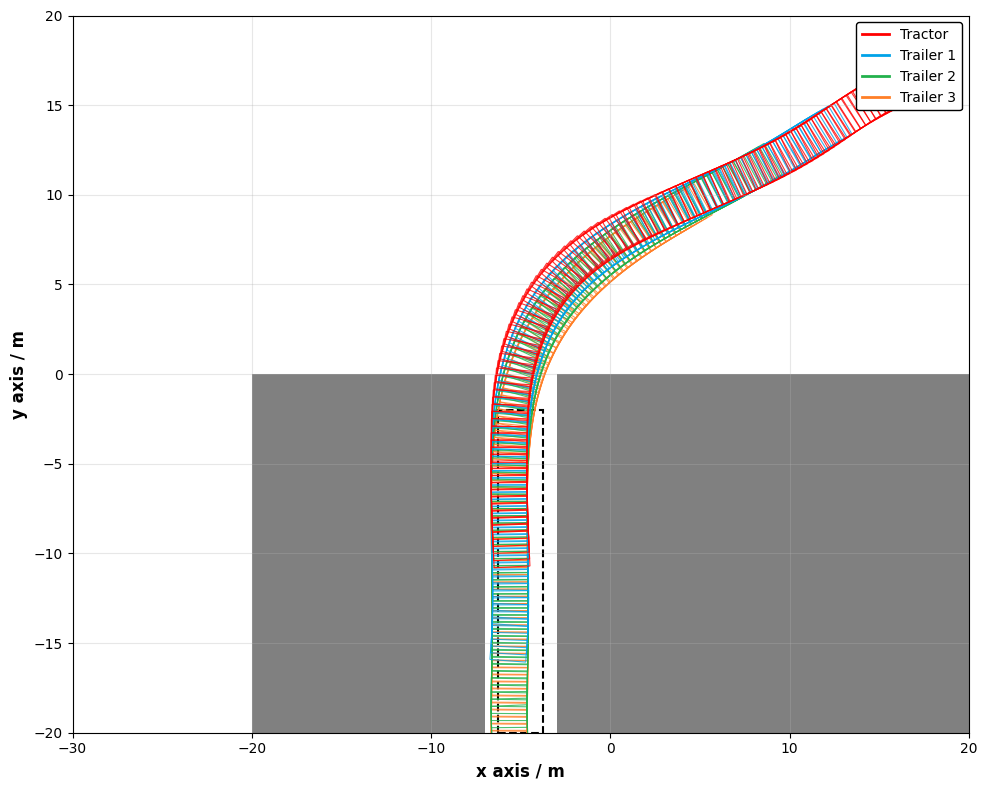

Generating progressive GIF animation (pcoc_animation.gif)...
GIF saved successfully as pcoc_animation.gif!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

def get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo):
    """Calculates the 4 corners of the tractor and all 3 trailers for plotting."""
    polygons = []
    LHW = geo['LHW']
    
    # 1. Tractor
    L_front = geo['L_tractor_front_hang']
    L_wb = geo['L_tractor_wheelbase']
    L_rear = geo['L_tractor_rear_hang']
    front_ext = L_front + L_wb
    tractor = np.array([
        [x1 + front_ext*np.cos(th1) - LHW*np.sin(th1), y1 + front_ext*np.sin(th1) + LHW*np.cos(th1)],
        [x1 + front_ext*np.cos(th1) + LHW*np.sin(th1), y1 + front_ext*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) + LHW*np.sin(th1), y1 - L_rear*np.sin(th1) - LHW*np.cos(th1)],
        [x1 - L_rear*np.cos(th1) - LHW*np.sin(th1), y1 - L_rear*np.sin(th1) + LHW*np.cos(th1)]
    ])
    polygons.append(tractor)
    
    # 2. Trailers
    x2, y2, x3, y3, x4, y4 = expand_from_6dim_to_xy(x1, y1, th1, th2, th3, th4, geo)
    trailer_states = [(x2, y2, th2), (x3, y3, th3), (x4, y4, th4)]
    t_front, t_rear = geo['L_trailer_front_hang'], geo['L_trailer_rear_hang']
    
    for (tx, ty, t_th) in trailer_states:
        trailer = np.array([
            [tx + t_front*np.cos(t_th) - LHW*np.sin(t_th), ty + t_front*np.sin(t_th) + LHW*np.cos(t_th)],
            [tx + t_front*np.cos(t_th) + LHW*np.sin(t_th), ty + t_front*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) + LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) - LHW*np.cos(t_th)],
            [tx - t_rear*np.cos(t_th) - LHW*np.sin(t_th), ty - t_rear*np.sin(t_th) + LHW*np.cos(t_th)]
        ])
        polygons.append(trailer)
        
    return polygons

def setup_paper_figure(obstacles, bvc, scale):
    """Sets up the canvas, obstacles, and goal box exactly like Bai Li's paper."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(scale['xmin'], scale['xmax'])
    ax.set_ylim(scale['ymin'], scale['ymax'])
    ax.set_aspect('equal')
    ax.grid(True, linestyle='-', alpha=0.3)
    ax.set_xlabel('x axis / m', fontsize=12, fontweight='bold')
    ax.set_ylabel('y axis / m', fontsize=12, fontweight='bold')
    
    for obs in obstacles:
        poly = patches.Polygon(np.column_stack((obs['x'], obs['y'])), closed=True, facecolor='gray', edgecolor='none')
        ax.add_patch(poly)
        
    goal_box = patches.Rectangle(
        (bvc['xc_end'] - bvc['x_end_half_width'], bvc['yc_end'] - bvc['y_end_half_width']),
        bvc['x_end_half_width'] * 2, bvc['y_end_half_width'] * 2,
        linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'
    )
    ax.add_patch(goal_box)
    
    colors = ['red', '#00A2E8', '#22B14C', '#FF7F27'] 
    labels = ['Tractor', 'Trailer 1', 'Trailer 2', 'Trailer 3']
    legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=labels[i]) for i in range(4)]
    
    ax.legend(handles=legend_elements, loc='upper right', framealpha=1, edgecolor='black')
    
    return fig, ax, colors

def plot_static_swept_volume(trajectory, obstacles, bvc, scale, geo):
    """Generates the static high-res image (Like Figure 5)."""
    print("Generating Static Swept Volume Plot...")
    fig, ax, colors = setup_paper_figure(obstacles, bvc, scale)
    
    N = len(trajectory['x'])
    
    for frame in range(N):
        x1, y1 = trajectory['x'][frame], trajectory['y'][frame]
        th1, th2, th3, th4 = trajectory['th1'][frame], trajectory['th2'][frame], trajectory['th3'][frame], trajectory['th4'][frame]
        
        polys = get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo)
        
        for i, poly in enumerate(polys):
            # facecolor='none' creates the hollow "wireframe" look
            p = patches.Polygon(poly, closed=True, facecolor='none', edgecolor=colors[i], linewidth=0.8, alpha=0.8)
            ax.add_patch(p)
            
    plt.tight_layout()
    plt.savefig("pcoc_figure_5.png", dpi=300) # Saves high-res image
    plt.show()

def create_swept_volume_gif(trajectory, obstacles, bvc, scale, geo, filename="pcoc_animation.gif"):
    """Generates an animated GIF that progressively draws the swept volume."""
    print(f"Generating progressive GIF animation ({filename})...")
    fig, ax, colors = setup_paper_figure(obstacles, bvc, scale)
    
    N = len(trajectory['x'])
    
    # Pre-calculate all patches, but start them invisible (alpha=0)
    all_frame_patches = []
    for frame in range(N):
        x1, y1 = trajectory['x'][frame], trajectory['y'][frame]
        th1, th2, th3, th4 = trajectory['th1'][frame], trajectory['th2'][frame], trajectory['th3'][frame], trajectory['th4'][frame]
        
        polys = get_vehicle_polygons(x1, y1, th1, th2, th3, th4, geo)
        frame_patches = []
        for i, poly in enumerate(polys):
            p = patches.Polygon(poly, closed=True, facecolor='none', edgecolor=colors[i], linewidth=0.8, alpha=0.0)
            ax.add_patch(p)
            frame_patches.append(p)
        all_frame_patches.append(frame_patches)

    def update(frame):
        for p in all_frame_patches[frame]:
            p.set_alpha(0.8) # Reveal the outline
        
        return [p for frame_list in all_frame_patches[:frame+1] for p in frame_list]

    anim = FuncAnimation(fig, update, frames=N, interval=50, blit=True)
    
    writer = PillowWriter(fps=20)
    anim.save(filename, writer=writer)
    print(f"GIF saved successfully as {filename}!")
    
    plt.close()
    
    return HTML(anim.to_jshtml())


plot_static_swept_volume(FINAL_TRAJECTORY, BASE_OBSTACLES, BVC, SCALE, GEO)

display(create_swept_volume_gif(FINAL_TRAJECTORY, BASE_OBSTACLES, BVC, SCALE, GEO))